## imports


In [1]:
import os
import sys
import matplotlib.pyplot as plt
import torch
import json
import pickle

from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from mne_connectivity import spectral_connectivity_time

import warnings
warnings.filterwarnings("ignore", message="Using padding='same'", category=UserWarning)

In [2]:
dir_base = Path("../..")
print(os.path.abspath(dir_base))

sys.path.append(os.path.abspath(dir_base))


c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg


In [3]:
%load_ext autoreload
%autoreload 2

from shallownetXAI_main.AllFnc.models import ShallowNet, ShallowNet2
from shallownetXAI_main.AllFnc.training import lossBinary, lossMulti, train_model, get_performances

from backend.ml.data_utils.load_data import *
from backend.ml.data_utils.prepare_data import *
from backend.experiments_xeegnet.xeegnet_with_conn import xEEGNetSCC


from backend.ml.model_vars import PRETRAINED_MODEL_DIR
from backend.ml.train import train_save_model, get_train_val_test_loader, PARAMETERS_DEFAULT, TRAINING_PARAMETERS_DEFAULT, save_model, load_model_weights
from main import load_participant_splits

from backend.ml.scc_cache import SCCStore, SCCParams, build_x_y_scc, CachedSCCDataset, SCCReducer, pairs_to_dense
from backend.experiments_xeegnet.model_evaluations import get_dataloaders_xysubjectids, split_data


from xeegnet_with_conn import BANDS


import selfeeg

c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### paths


In [4]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
dir_data_abs = os.path.abspath(dir_data)
data_path = os.path.join(dir_data, "sub-001", "eeg", "sub-001_task-eyesclosed_eeg.set")

dir_data_outer = os.path.join(dir_base, "data")

dir_shallownetXAI = os.path.join(
    dir_base, "backend", "experiments_xeegnet", "shallownetXAI_main"
)

# data_path = os.path.join(dir_data_abs, 'ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set')

#### settings


In [38]:
pipelineToEval = "filt"  #'icasr'
taskToEval = "alzheimer"
modelToEval = "shallownet_custom"  # shallownet, shallownet_custom
outFold = 1
inFold = 5
downsample = True
z_score = True
rem_interp = True
batchsize = 64
overlap = 0.0
workers = 0
window = 4
verbose = True
lr = 5 * 10 ** (-5)
epochs = 1000
lossVal = None
arch_acronym = "shn7db"
seed = 83136297

nb_classes = 3
Chans = 19
srate = 125 if downsample else 250

sample_length = 125 * 4  # srate * window

# SET DEVICE: 0 = ZANOLA
if torch.cuda.is_available():
    device = torch.device(0)
else:
    device = torch.device("cpu")
print(device)

cpu


In [6]:
# Med-ShallowNet
shallownet_custom_dict = {
    "F1": 7,
    "K1": 125,
    "F2": 7,
    "Pool": 75,
    "p": 0.2,
    "log_activation_base": "dB",
    "norm_type": "batchnorm",
    "random_temporal_filter": False,
    "Fs": 125 if downsample else 250,
    "freeze_temporal": 999999999,
    "dense_hidden": None,
    "spatial_depthwise": True,
    "spatial_only_positive": False,
    "global_pooling": True,
    "bias": [False, False, False],
    "return_logits": True,
    "seed": seed,
}

# Read Data


In [8]:
df_metadata = load_metadata(dir_data)

# data = load_multiple_eeg_windows_inner(
#     dir_data=dir_data,
#     participant_ids=[1,2],
#     df_metadata=df_metadata,
#     sample_length=sample_length,
#     n_max = 500
# )

# data[2]

In [9]:
# participant_ids = [2,3]

# 4 - 88
participant_ids = np.arange(1, 89).tolist()
print(participant_ids)
# participant_ids

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88]


In [10]:
path=Path(dir_data_outer) / "scc_cache" / "ds004504" / "derivatives" 

store  = SCCStore(
    root=Path(dir_data_outer) / "scc_cache" 
)
scc_params = SCCParams.default(sfreq=srate, sample_length=sample_length)

source = "derivatives"
dataset_id = "ds004504"

In [13]:
# df_metadata   = load_metadata(dir_data)
label_of = {f"sub-{int(r.participant_id.split('-')[1]):03d}": int(r.group_encoded)
            for r in df_metadata.itertuples()}

In [ ]:
x, y, scc, data_subject_ids = build_x_y_scc(
    dir_data=dir_data,
    participant_ids=participant_ids,
    label_of_subject=label_of,
    store=store,
    params=scc_params,
    load_model_windows_for_participant=load_model_windows_for_participant,
    dataset_id=dataset_id,
    n_channels=Chans,
    source=source,
    sample_length=sample_length,
    n_jobs=1,
    print_info=True,
)

data_x_y_scc_id = (x, y, scc, data_subject_ids)
data_x_y_id = (x, y, data_subject_ids)
# data_x_y_id = (x, y, data_subject_ids)

  cache hit for sub-001 (derivatives) -> (149, 7, 171)
  cache hit for sub-002 (derivatives) -> (198, 7, 171)
  cache hit for sub-003 (derivatives) -> (76, 7, 171)
  cache hit for sub-004 (derivatives) -> (176, 7, 171)
  cache hit for sub-005 (derivatives) -> (201, 7, 171)
  cache hit for sub-006 (derivatives) -> (158, 7, 171)
  cache hit for sub-007 (derivatives) -> (191, 7, 171)
  cache hit for sub-008 (derivatives) -> (198, 7, 171)
  cache hit for sub-009 (derivatives) -> (153, 7, 171)
  cache hit for sub-010 (derivatives) -> (320, 7, 171)
  cache hit for sub-011 (derivatives) -> (192, 7, 171)
  cache hit for sub-012 (derivatives) -> (220, 7, 171)
  cache hit for sub-013 (derivatives) -> (209, 7, 171)
  cache hit for sub-014 (derivatives) -> (233, 7, 171)
  cache hit for sub-015 (derivatives) -> (225, 7, 171)
  cache hit for sub-016 (derivatives) -> (243, 7, 171)
  cache hit for sub-017 (derivatives) -> (210, 7, 171)
  cache hit for sub-018 (derivatives) -> (211, 7, 171)
  cache hit

## Built Models


### xeegnet + spectral connectivity


In [21]:
def build_xeegnet_scc(nb_classes=3, Chans=19, Samples=125 * 4, Fs=125):
    base = selfeeg.models.xEEGNet(
        nb_classes=3,
        Chans=19,
        Samples=125 * 4,
        Fs=125,
        global_pooling=True,
    )
    # Wrapper with cached spectral connectivity pairs
    xeegnet_scc = xEEGNetSCC(base_model=base, reducer_mode="mean")
    return xeegnet_scc

In [22]:
# Base xEEGNet
base = selfeeg.models.xEEGNet(
    nb_classes=3,
    Chans=19,
    Samples=125 * 4,
    Fs=125,
    global_pooling=True,
 )
# Wrapper with cached spectral connectivity pairs
xeegnet_scc = xEEGNetSCC(base_model=base, reducer_mode="mean")


### Other Models


In [26]:
# For selfEEG's models instantiation
sample_length = int(srate * window)
shallow_net_2 = ShallowNet2(
    nb_classes=nb_classes, Chans=Chans, Samples=sample_length, seed=seed
)
shallow_net = ShallowNet(
    nb_classes=nb_classes, Chans=Chans, Samples=sample_length, seed=seed
)

xeegnet = selfeeg.models.xEEGNet(
    nb_classes=nb_classes,
    Chans=Chans,
    Samples=sample_length,
    Fs=125 if downsample else 250,
    global_pooling=True,
)

#### Test forward pass


In [30]:
n_batches = 10

x = torch.randn(n_batches, Chans, sample_length, dtype=torch.float32)
scc_pairs = torch.randn(n_batches, len(BANDS), Chans*(Chans-1)//2, dtype=torch.float32)

out = xeegnet_scc([x, scc_pairs])
print(out.shape)  # shoud return torch.Size([3, 3])
print(torch.isnan(out).sum())  # shoud return 0
out

torch.Size([10, 3])
tensor(0)


tensor([[-1.2146, -0.2858, -0.5986],
        [-0.4158, -0.0299,  0.5551],
        [ 0.5141, -0.5621,  0.4001],
        [-0.1658,  0.8460, -0.2878],
        [-0.4472, -0.0372, -0.2311],
        [ 0.5779, -0.1349,  0.2470],
        [ 0.3352,  0.1309,  0.0373],
        [ 1.1333, -0.1622, -0.6483],
        [-0.4408,  0.5823, -0.0507],
        [ 0.0793, -1.2869,  0.3036]], grad_fn=<MmBackward0>)

In [32]:
out = xeegnet(x)
print(out.shape)  # shoud return torch.Size([3, 3])
out

torch.Size([10, 3])


tensor([[-0.8962,  0.1087,  1.3542],
        [ 0.7307, -0.3391,  0.7674],
        [ 0.3171, -0.4132, -0.1090],
        [-0.0747,  0.3586,  1.9655],
        [-0.2429,  0.0774, -0.3840],
        [-0.1242, -0.1357,  0.9779],
        [ 0.9530,  0.7207, -0.5157],
        [-0.1942, -0.4130,  0.2550],
        [ 0.1008,  1.3190, -0.8895],
        [ 0.8344, -0.6380, -0.8231]], grad_fn=<MmBackward0>)

# train models


### functions


In [35]:
from sklearn.metrics import balanced_accuracy_score
from model_evaluations import *

In [39]:
def build_model_for_version(model_kind: str, nb_classes: int, Chans: int, sample_length: int, srate: int):
    model_kind = model_kind.casefold()
    if model_kind == "xeegnet_scc":
        base_model = selfeeg.models.xEEGNet(
            nb_classes=nb_classes,
            Chans=Chans,
            Samples=sample_length,
            Fs=srate,
            global_pooling=True,
        )
        return xEEGNetSCC(base_model=base_model, reducer_mode="mean")
    if model_kind == "xeegnet":
        return selfeeg.models.xEEGNet(
            nb_classes=nb_classes,
            Chans=Chans,
            Samples=sample_length,
            Fs=srate,
            global_pooling=True,
        )
    if model_kind == "shallownet":
        return ShallowNet(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, seed=seed)
    raise ValueError(f"Unsupported model_kind: {model_kind}")


def _predict_from_loader(model, loader, device):
    model.eval()
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for inputs, targets in loader:
            targets_np = targets.detach().cpu().numpy()
            if isinstance(inputs, (list, tuple)):
                x_batch = inputs[0].to(device)
                scc_batch = inputs[1].to(device)
                outputs = model([x_batch, scc_batch])
            else:
                outputs = model(inputs.to(device))
            predictions = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            y_true_all.extend(targets_np.tolist())
            y_pred_all.extend(predictions.tolist())

    return np.asarray(y_true_all), np.asarray(y_pred_all)


def _compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def train_and_evaluate_model_version(
    model_version: int,
    model_kind: str = "xeegnet_scc",
    *,
    dir_data: str = dir_data,
    dir_data_outer: str = dir_data_outer,
    parameters: dict = PARAMETERS_DEFAULT,
    nb_classes: int = nb_classes,
    Chans: int = Chans,
    sample_length: int = sample_length,
    srate: int = srate,
    device: torch.device = device,
    lr: float = lr,
    verbose: bool = verbose,
    task_to_eval: str = taskToEval,
    n_max: int | None = None,
    train_epochs: int = 100,
    do_train: bool = True,
    do_evaluate: bool = True,
    save_model_flag: bool = True,
    store: SCCStore | None = None,
    scc_params: SCCParams | None = None,
    load_model_windows_for_participant=None,
    data_x_y_id: tuple[np.ndarray, np.ndarray, np.ndarray] | None = None,
    data_x_y_scc_id: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray] | None = None,  
):
    split_index = model_version - 200
    split_path = Path(dir_base) / "backend" / "ml" / "data_splits.json"
    participants_split = load_participant_splits(split_path=split_path)[str(split_index)]

    df_metadata = load_metadata(dir_data=dir_data)
    df_metadata["datasplit"] = "test"
    df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
    df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"

    model_curr = build_model_for_version(model_kind, nb_classes, Chans, sample_length, srate)
    model_curr = model_curr.to(device)

    if model_kind.casefold() == "xeegnet_scc":
        if load_model_windows_for_participant is None:
            load_model_windows_for_participant = globals().get("load_model_windows_for_participant")
        if load_model_windows_for_participant is None:
            raise ValueError("load_model_windows_for_participant is required for xeegnet_scc evaluation/training.")
        if store is None:
            store = SCCStore(root=Path(dir_data_outer) / "scc_cache")
        if scc_params is None:
            scc_params = SCCParams.default(sfreq=srate, sample_length=sample_length)

        trainloader, valloader, testloader, _ = get_dataloaders_xysubjectids(
            dir_data=dir_data,
            participant_ids_train=participants_split["train"],
            participant_ids_val=participants_split["val"],
            participant_ids_test=participants_split["test"],
            df_metadata=df_metadata,
            parameters=parameters,
            n_max=n_max,
            use_cached_scc=True,
            store=store,
            scc_params=scc_params,
            dataset_id="ds004504",
            n_channels=Chans,
            source="derivatives",
            load_model_windows_for_participant=load_model_windows_for_participant,
            data_x_y_id=data_x_y_id,
            data_x_y_scc_id=data_x_y_scc_id
        )
    else:
        trainloader, valloader, testloader, _ = get_dataloaders_xysubjectids(
            dir_data=dir_data,
            participant_ids_train=participants_split["train"],
            participant_ids_val=participants_split["val"],
            participant_ids_test=participants_split["test"],
            df_metadata=df_metadata,
            parameters=parameters,
            n_max=n_max,
            use_cached_scc=False,
            data_x_y_id=data_x_y_id,
            data_x_y_scc_id=data_x_y_scc_id
        )

    loss_fnc = lossMulti if task_to_eval.casefold() == "alzheimer" or ("cognitive" in task_to_eval.casefold()) else lossBinary
    earlystop_local = selfeeg.ssl.EarlyStopping(patience=15, min_delta=1e-04, record_best_weights=True)
    optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.995)

    if do_train:
        train_model(
            model=model_curr,
            train_dataloader=trainloader,
            epochs=train_epochs,
            optimizer=optimizer,
            loss_func=loss_fnc,
            lr_scheduler=scheduler,
            EarlyStopper=earlystop_local,
            validation_dataloader=valloader,
            validation_loss_func=lossVal,
            validation_loss_args=validation_loss_args,
            verbose=verbose,
            device=device,
            return_loss_info=True,
        )

    model_type = model_kind.casefold()
    if model_type == "xeegnet_scc":
        model_name = f"xeegnet_scc_model_v{model_version}.pt" if not n_max else f"xeegnet_scc_model_v{model_version}_nmax{n_max}.pt"
    elif model_type == "xeegnet":
        model_name = f"xeegnet_model_v{model_version}.pt" if not n_max else f"xeegnet_model_v{model_version}_nmax{n_max}.pt"
    elif model_type == "shallownet":
        model_name = f"shallownet_model_v{model_version}.pt" if not n_max else f"shallownet_model_v{model_version}_nmax{n_max}.pt"
    else:
        raise ValueError(f"Unsupported model_kind: {model_kind}")

    model_path = PRETRAINED_MODEL_DIR / model_name
    if save_model_flag and do_train:
        save_model(model_curr, model_path)

    result = {
        "model_version": model_version,
        "model_kind": model_kind,
        "model_name": model_name,
        "model_path": str(model_path),
        "train_epochs": train_epochs,
    }

    if do_evaluate:
        y_true, y_pred = _predict_from_loader(model_curr, testloader, device)
        result.update(_compute_metrics(y_true, y_pred))
        result["n_test_samples"] = len(y_true)

    return result


def evaluate_model_version(
    model_version: int,
    model_kind: str = "xeegnet_scc",
    *,
    dir_data: str = dir_data,
    dir_data_outer: str = dir_data_outer,
    parameters: dict = PARAMETERS_DEFAULT,
    nb_classes: int = nb_classes,
    Chans: int = Chans,
    sample_length: int = sample_length,
    srate: int = srate,
    device: torch.device = device,
    verbose: bool = verbose,
    task_to_eval: str = taskToEval,
    n_max: int | None = None,
    store: SCCStore | None = None,
    scc_params: SCCParams | None = None,
    load_model_windows_for_participant=None,
    data_x_y_id: tuple[np.ndarray, np.ndarray, np.ndarray] | None = None,
    data_x_y_scc_id: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray] | None = None,
):
    return train_and_evaluate_model_version(
        model_version=model_version,
        model_kind=model_kind,
        dir_data=dir_data,
        dir_data_outer=dir_data_outer,
        parameters=parameters,
        nb_classes=nb_classes,
        Chans=Chans,
        sample_length=sample_length,
        srate=srate,
        device=device,
        lr=lr,
        verbose=verbose,
        task_to_eval=task_to_eval,
        n_max=n_max,
        train_epochs=0,
        do_train=False,
        do_evaluate=True,
        save_model_flag=False,
        store=store,
        scc_params=scc_params,
        load_model_windows_for_participant=load_model_windows_for_participant,
        data_x_y_id=data_x_y_id,
        data_x_y_scc_id=data_x_y_scc_id
    )

### Running


In [102]:
# n_max = 300
# max_epochs = 5

n_max = None
max_epochs = 100

do_evaluate = True
do_train = True
save_model_flag = True
scc_params = SCCParams.default(sfreq=srate, sample_length=sample_length)

parameters = PARAMETERS_DEFAULT
training_parameters = TRAINING_PARAMETERS_DEFAULT
# dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")

In [ ]:
source = "derivatives"
dataset_id = "ds004504"

label_of = {
    f"sub-{int(r.participant_id.split('-')[1]):03d}": int(r.group_encoded)
    for r in df_metadata.itertuples()
}

x, y, scc, data_subject_ids = build_x_y_scc(
    dir_data=dir_data,
    participant_ids=participant_ids,
    label_of_subject=label_of,
    store=store,
    params=scc_params,
    load_model_windows_for_participant=load_model_windows_for_participant,
    dataset_id=dataset_id,
    n_channels=Chans,
    source=source,
    sample_length=sample_length,
    n_jobs=1,
    print_info=True,
)

data_x_y_scc_id = (x, y, scc, data_subject_ids)
# data_x_y_id = (x, y, data_subject_ids)

In [ ]:
if True:
        
    multi_model_results = []

    for model_version in range(200, 205):

        print(f"Training and evaluating model version: {model_version}")

        run_result = train_and_evaluate_model_version(
            model_version=model_version,
            model_kind="xeegnet_scc",
            dir_data=dir_data,
            dir_data_outer=dir_data_outer,
            parameters=PARAMETERS_DEFAULT,
            nb_classes=nb_classes,
            Chans=Chans,
            sample_length=sample_length,
            srate=srate,
            device=device,
            lr=lr,
            verbose=verbose,
            task_to_eval=taskToEval,
            n_max=n_max,
            train_epochs=max_epochs,
            do_train=do_train,
            do_evaluate=do_evaluate,
            save_model_flag=save_model_flag,
            store=store,
            scc_params=scc_params,
            load_model_windows_for_participant=load_model_windows_for_participant,
            data_x_y_id=data_x_y_id,
            data_x_y_scc_id=data_x_y_scc_id
        )
        multi_model_results.append(run_result)

    results_df = pd.DataFrame(multi_model_results)
    results_df = results_df.sort_values("model_version").reset_index(drop=True)
    print(results_df)

    metrics_csv_path = PRETRAINED_MODEL_DIR / "xeegnet_scc_model_versions_200_204_metrics.csv"
    results_df.to_csv(metrics_csv_path, index=False)
    # print(f"Saved metrics to {metrics_csv_path}")

    results_df

In [104]:
# df_metadata

In [105]:
# model_version

### Evaluate models


In [ ]:
def evaluate_saved_model(model_path, model_kind):
    model_path = Path(model_path)
    model_version = int(model_path.stem.split("_v")[-1].split("_")[0])
    metrics = evaluate_model_version(
        model_version=model_version,
        model_kind=model_kind,
        dir_data=dir_data,
        dir_data_outer=dir_data_outer,
        parameters=PARAMETERS_DEFAULT,
        nb_classes=nb_classes,
        Chans=Chans,
        sample_length=sample_length,
        srate=srate,
        device=device,
        verbose=verbose,
        task_to_eval=taskToEval,
        n_max=None,
        store=store,
        scc_params=scc_params,
        load_model_windows_for_participant=load_model_windows_for_participant,
        data_x_y_scc_id=data_x_y_scc_id
    )
    metrics["model_path"] = str(model_path)
    return metrics


saved_model_runs = []
for model_kind, model_prefix in [("xeegnet", "xeegnet_model"), ("xeegnet_scc", "xeegnet_scc_model")]:
    for model_version in range(200, 205):
        saved_model_runs.append(
            {
                "model_kind": model_kind,
                "model_path": PRETRAINED_MODEL_DIR / f"{model_prefix}_v{model_version}.pt",
            }
        )

saved_model_results = []
for run in saved_model_runs:

    print(f"Evaluating saved model: {run['model_kind']} at {run['model_path']}")

    saved_model_results.append(evaluate_saved_model(run["model_path"], run["model_kind"]))

saved_model_results_df = pd.DataFrame(saved_model_results).sort_values(["model_kind", "model_version"]).reset_index(drop=True)


saved_model_results_name = PRETRAINED_MODEL_DIR / "saved_model_versions_200_204_metrics.csv"
saved_model_results_df.to_csv(saved_model_results_name, index=False)

# saved_model_results_df

# saved_model_results_df

Evaluating saved model: xeegnet at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt
Evaluating saved model: xeegnet at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v201.pt
Evaluating saved model: xeegnet at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v202.pt
Evaluating saved model: xeegnet at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v203.pt
Evaluating saved model: xeegnet at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v204.pt
Evaluating saved model: xeegnet_scc at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_v200.pt
Evaluating saved model: xeegnet_scc at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml

In [115]:
saved_model_results_df.sort_values(["model_version", "model_kind"]).reset_index(drop=True)


,model_version,model_kind,model_name,model_path,train_epochs,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,precision_weighted,recall_macro,recall_weighted,n_test_samples
0,200,xeegnet,xeegnet_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,0.354051,0.362791,0.226922,0.217716,0.300669,0.277078,0.362791,0.354051,3604
1,200,xeegnet_scc,xeegnet_scc_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,0.290233,0.294273,0.209122,0.205969,0.266229,0.257690,0.294273,0.290233,3604
2,201,xeegnet,xeegnet_model_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,0.348702,0.334121,0.174298,0.181913,0.282789,0.296091,0.334121,0.348702,3622
3,201,xeegnet_scc,xeegnet_scc_model_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,0.300939,0.331732,0.155242,0.140941,0.151772,0.144659,0.331732,0.300939,3622
4,202,xeegnet,xeegnet_model_v202.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,0.350410,0.335887,0.258039,0.262869,0.237152,0.236145,0.335887,0.350410,3416
5,202,xeegnet_scc,xeegnet_scc_model_v202.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,0.332845,0.331538,0.167475,0.168203,0.166699,0.172066,0.331538,0.332845,3416
6,203,xeegnet,xeegnet_model_v203.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,0.359457,0.333333,0.176275,0.190090,0.119819,0.129209,0.333333,0.359457,3611
7,203,xeegnet_scc,xeegnet_scc_model_v203.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,0.301302,0.333171,0.164249,0.149545,0.270132,0.263702,0.333171,0.301302,3611
8,204,xeegnet,xeegnet_model_v204.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,0.299633,0.296206,0.244559,0.249026,0.379194,0.368582,0.296206,0.299633,3274
9,204,xeegnet_scc,xeegnet_scc_model_v204.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,0.324985,0.333020,0.163818,0.159865,0.108627,0.106006,0.333020,0.324985,3274


## train & evaluate single models


In [158]:
# model = shallow_net
# model_curr = xeegnet
model_curr = build_xeegnet_scc(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, Fs=srate)


In [159]:
optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
gamma = 0.995
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

# factor = 0.5
# patience_scheduler = 10
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=factor, patience=patience_scheduler)

# Define selfEEG's EarlyStopper with large patience to act as a model checkpoint
earlystop = selfeeg.ssl.EarlyStopping(
    patience=15, min_delta=1e-04, record_best_weights=True
)

validation_loss_args = []
if taskToEval.casefold() == "alzheimer" or ("cognitive" in taskToEval.casefold()):
    lossFnc = lossMulti
else:
    lossFnc = lossBinary

In [74]:
# def load_participant_splits(split_path=None) -> dict[str, dict[str, list[int]]]:
#     if split_path is None:
#         split_path = Path("backend") / "ml" / "data_splits.json"
#     with split_path.open("r", encoding="utf-8") as file:
#         return json.load(file)

In [ ]:
model_version = 200

n_max = 1500
n_max = None

parameters = PARAMETERS_DEFAULT
training_parameters = TRAINING_PARAMETERS_DEFAULT
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")


In [108]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
split_index = model_version - 200

if isinstance(model_curr, xEEGNetSCC):
    model_type = f"xeegnet_scc_model"
elif isinstance(model_curr, selfeeg.models.xEEGNet):
    model_type = f"xeegnet_model"
elif isinstance(model_curr, ShallowNet):
    model_type = f"shallownet_model"


if not n_max:
    modelname = f"{model_type}_v{model_version}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname
else:
    modelname = f"{model_type}_v{model_version}_nmax{n_max}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname

print(f"Model name: {modelname}")
print(f"Model path: {model_path}")

split_path = Path(dir_base) / "backend" / "ml" / "data_splits.json"

participants_split = load_participant_splits(split_path=split_path)[str(split_index)]

df_metadata = load_metadata(dir_data=dir_data)
df_metadata["datasplit"] = "test"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"

participant_ids_train = participants_split["train"]
participant_ids_val = participants_split["val"]
participant_ids_test = participants_split["test"]

participant_ids_train_str = [gen_participant_id_long(pid) for pid in participant_ids_train]
participant_ids_val_str = [gen_participant_id_long(pid) for pid in participant_ids_val]
participant_ids_test_str = [gen_participant_id_long(pid) for pid in participant_ids_test]


Model name: xeegnet_scc_model_v200.pt
Model path: C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_v200.pt


In [109]:
# df_metadata, trainloader, valloader, testloader, xy = get_train_val_test_loader(
#     dir_data=dir_data,
#     df_metadata=df_metadata,
#     participant_ids_train=participants_split["train"],
#     participant_ids_val=participants_split["val"],
#     n_max=n_max
# )


# x_train, y_train, x_val, y_val, x_test, y_test = xy

In [111]:
# n_max

In [112]:
# check if model curr is scc

if isinstance(model_curr, xEEGNetSCC):
    print("model_curr is xEEGNetSCC; using cached SCC for dataloaders.")

    store  = SCCStore(
        root=Path(dir_data_outer) / "scc_cache" 
    )
    scc_params = SCCParams.default(sfreq=srate, sample_length=sample_length)

    trainloader, valloader, testloader, xy_subjects = get_dataloaders_xysubjectids(
    dir_data=dir_data,
    participant_ids_train=participant_ids_train,
    participant_ids_val=participant_ids_val,
    df_metadata=df_metadata,
    parameters=PARAMETERS_DEFAULT,
    n_max=n_max,
    use_cached_scc=True,
    store=store,
    scc_params=scc_params,
    dataset_id="ds004504",
    n_channels=Chans,
    source="derivatives",
    load_model_windows_for_participant=load_model_windows_for_participant,
)
else:
    trainloader, valloader, testloader, xy_subjects = get_dataloaders_xysubjectids(
        dir_data=dir_data,
        participant_ids_train=participant_ids_train,
        participant_ids_val=participant_ids_val,
        df_metadata=df_metadata,
        parameters=parameters,
        use_cached_scc=False,
        n_max=n_max,
    )

x_train, y_train, subject_ids_train, x_val, y_val, subject_ids_val, x_test, y_test, subject_ids_test = xy_subjects

model_curr is xEEGNetSCC; using cached SCC for dataloaders.
Loaded x (10981, 19, 500), scc (10981, 7, 171), y (10981,)
Loaded x (3274, 19, 500), scc (3274, 7, 171), y (3274,)
Loaded x (3164, 19, 500), scc (3164, 7, 171), y (3164,)


In [113]:
loss_summary = train_model(
    model=model_curr,
    train_dataloader=trainloader,
    epochs=100,
    optimizer=optimizer,
    loss_func=lossFnc,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader,
    validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

save_model(model_curr, model_path)

epoch [1/100]
   val 52/52: 100%|███████████████| 224/224 [57.80 Batch/s, train_loss=2.57971, val_loss=2.35622]  
epoch [2/100]
   val 52/52: 100%|███████████████| 224/224 [58.46 Batch/s, train_loss=2.21775, val_loss=1.95927]  
epoch [3/100]
   val 52/52: 100%|███████████████| 224/224 [59.36 Batch/s, train_loss=1.93654, val_loss=1.67259]  
epoch [4/100]
   val 52/52: 100%|███████████████| 224/224 [59.67 Batch/s, train_loss=1.73289, val_loss=1.56308]  
epoch [5/100]
   val 52/52: 100%|███████████████| 224/224 [59.23 Batch/s, train_loss=1.59760, val_loss=1.44505]  
epoch [6/100]
   val 52/52: 100%|███████████████| 224/224 [60.58 Batch/s, train_loss=1.48459, val_loss=1.34726]  
epoch [7/100]
   val 52/52: 100%|███████████████| 224/224 [60.06 Batch/s, train_loss=1.39905, val_loss=1.29317]  
epoch [8/100]
   val 52/52: 100%|███████████████| 224/224 [58.36 Batch/s, train_loss=1.32774, val_loss=1.25080]  
epoch [9/100]
   val 52/52: 100%|███████████████| 224/224 [59.46 Batch/s, train_loss=1.2

## Evaluate model


In [162]:
def get_performances_metrics(y_true, y_pred):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
    }
    return metrics

In [160]:
from backend.ml.model import build_xeegnet

In [65]:
# model = model_curr

In [166]:
print(f"model version {model_version} ")
print(f"n_max: {n_max} ")

reload = True

n_max = None

# model_type = "xeegnet_scc"
model_type = "xeegnet"

if n_max:
    model_name = f"{model_type}_model_v{model_version}_nmax{n_max}.pt"
else:
    model_name = f"{model_type}_model_v{model_version}.pt"

model_path = PRETRAINED_MODEL_DIR / model_name
print(f"model path: {model_path}")

if reload:
    print(f"Reloading model from {model_path}...")
    if model_type == "xeegnet":
        model = build_xeegnet()

    elif model_type == "xeegnet_scc":
        model = build_xeegnet_scc()

    model = load_model_weights(model_path, model=model, device=device)

else:
    model = model_curr


model version 200 
n_max: None 
model path: C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt
Reloading model from C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt...
Loading model from C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_curr = model_curr.to(device)
model_curr = model

# cast from torch.cuda.FloatTensor to torch.FloatTensor
# x_train_eeg = torch.Tensor(x_train)
# x_train = x_train.to(device)

if isinstance(model_curr, xEEGNetSCC):
    print("Evaluating xEEGNetSCC with cached SCC inputs.")
    eval_store = store
    eval_params = scc_params
    eval_df = load_metadata(dir_data)
    eval_label_of = {f"sub-{int(r.participant_id.split('-')[1]):03d}": int(r.group_encoded) for r in eval_df.itertuples()}

    def eval_split(participant_ids: list[int], split_name: str):
        x_eval, y_eval, scc_eval, _ = build_x_y_scc(
            dir_data,
            participant_ids,
            eval_label_of,
            eval_store,
            eval_params,
            load_model_windows_for_participant,
            dataset_id="ds004504",
            n_channels=Chans,
            source="derivatives",
            sample_length=sample_length,
        )
        x_eval_t = torch.as_tensor(x_eval, dtype=torch.float32, device=device)
        scc_eval_t = torch.as_tensor(scc_eval, dtype=torch.float32, device=device)
        with torch.no_grad():
            y_out = model_curr([x_eval_t, scc_eval_t])
        y_pred = torch.argmax(y_out, dim=1).detach().cpu().numpy()
        metrics = get_performances_metrics(y_eval, y_pred)
        print(f"Evaluating on {split_name} set:")
        print(metrics)
        print("\n")

    eval_split(participant_ids_train, "train")
    eval_split(participant_ids_val, "val")
    eval_split(participant_ids_test, "test")
else:
    for dataset_type, x_data, y_data in zip(
        ["train", "val", "test"], [x_train, x_val, x_test], [y_train, y_val, y_test]
    ):
        print(f"Evaluating on {dataset_type} set:")
        x_data = torch.Tensor(x_data)
        x_data = x_data.to(device)
        with torch.no_grad():
            y_out = model_curr(x_data)
        y_pred = torch.argmax(y_out, dim=1).detach().cpu().numpy()
        metrics = get_performances_metrics(y_data, y_pred)
        print(metrics)
        print("\n")

Evaluating on train set:
{'accuracy': 0.7423731900555505, 'f1_macro': 0.6930250193508659, 'precision_macro': 0.7544014161026631, 'recall_macro': 0.6919962821579189}


Evaluating on val set:
{'accuracy': 0.5436774587660355, 'f1_macro': 0.48000562396124496, 'precision_macro': 0.5094921488241387, 'recall_macro': 0.5208795765692115}


Evaluating on test set:
{'accuracy': 0.5300252844500632, 'f1_macro': 0.42312599895775227, 'precision_macro': 0.4136975828519291, 'recall_macro': 0.4483254483135887}




           |-----------------------------------------|
           |                SCORE SUMMARY            |
           |-----------------------------------------|
           |  Accuracy score:                 0.530  |
           |  Accuracy score weighted:        0.448  |
           |-----------------------------------------|
           |  Precision score micro:          0.530  |
           |  Precision score macro:          0.414  |
           |  Precision score weighted:       0.485  |
           |-----------------------------------------|
           |  Recall score micro:             0.530  |
           |  Recall score macro:             0.448  |
           |  Recall score weighted:          0.530  |
           |-----------------------------------------|
           |  F1-score micro:                 0.530  |
           |  F1-score macro:                 0.423  |
           |  F1-score weighted:              0.500  |
           |-----------------------------------------|
          

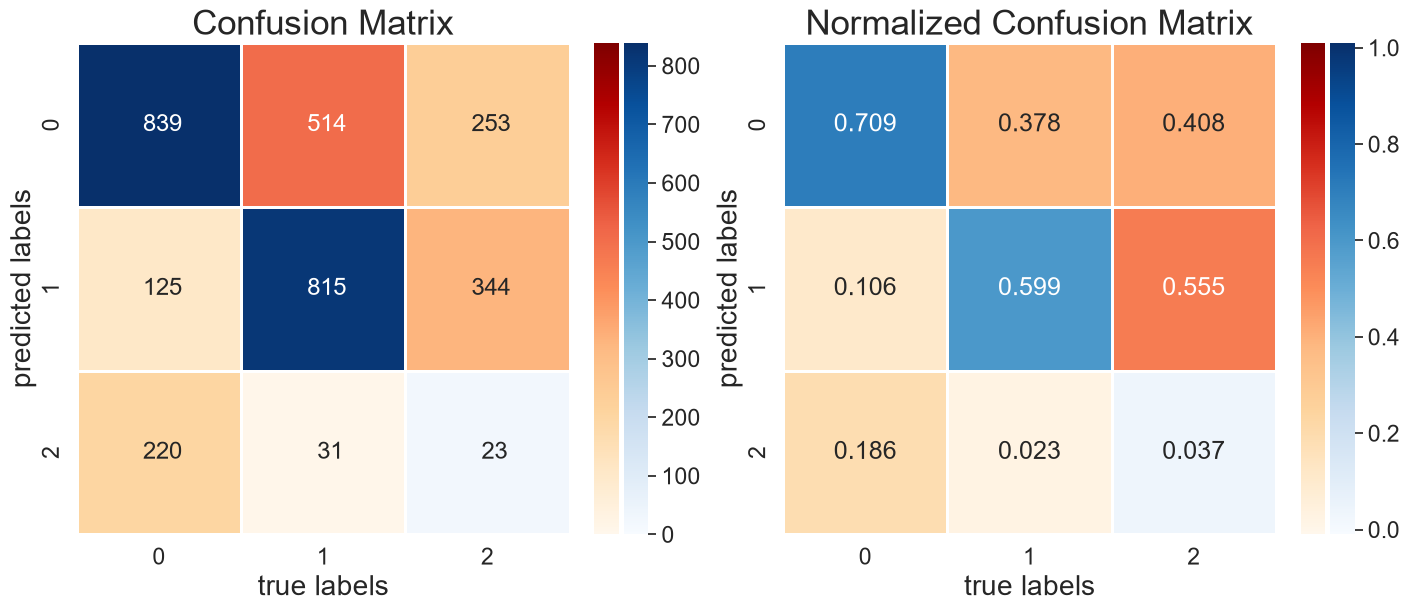

Balanced Accuracy:  44.83 %


In [168]:
classlabels = y_test

if isinstance(model_curr, xEEGNetSCC):
    scores = get_performances(
        loader2eval=testloader_scc,
        Model=model_curr,
        device=device,
        nb_classes=nb_classes,
        return_scores=True,
        verbose=verbose,
        plot_confusion=True,
        class_labels=classlabels,
    )
else:
    scores = get_performances(
        loader2eval=testloader,
        Model=model_curr,
        device=device,
        nb_classes=nb_classes,
        return_scores=True,
        verbose=verbose,
        plot_confusion=True,
        class_labels=classlabels,
    )
print(f"Balanced Accuracy: {scores['accuracy_weighted'] * 100: .2f} %")

#### shallow net 2


In [ ]:
if False:
    loss_summary = train_model(
        model=shallow_net_2,
        train_dataloader=trainloader,
        epochs=30,
        optimizer=optimizer,
        loss_func=lossFnc,
        lr_scheduler=scheduler,
        EarlyStopper=earlystop,
        validation_dataloader=valloader,
        validation_loss_func=lossVal,
        validation_loss_args=validation_loss_args,
        verbose=verbose,
        device=device,
        return_loss_info=True,
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    shallow_net = shallow_net.to(device)

    # cast from torch.cuda.FloatTensor to torch.FloatTensor
    # x_train_eeg = torch.Tensor(x_train)
    x_train = x_train.to(device)
    y_train_out = shallow_net(x_train)
    y_train_pred = torch.argmax(y_train_out, dim=1).detach().cpu().numpy()

    print("ShallowNet 2 performance on training set:")
    get_performances_metrics(y_train, y_train_pred)

## Scores


           |-----------------------------------------|
           |                SCORE SUMMARY            |
           |-----------------------------------------|
           |  Accuracy score:                 0.167  |
           |  Accuracy score weighted:        0.167  |
           |-----------------------------------------|
           |  Precision score micro:          0.167  |
           |  Precision score macro:          0.083  |
           |  Precision score weighted:       0.083  |
           |-----------------------------------------|
           |  Recall score micro:             0.167  |
           |  Recall score macro:             0.167  |
           |  Recall score weighted:          0.167  |
           |-----------------------------------------|
           |  F1-score micro:                 0.167  |
           |  F1-score macro:                 0.111  |
           |  F1-score weighted:              0.111  |
           |-----------------------------------------|
          

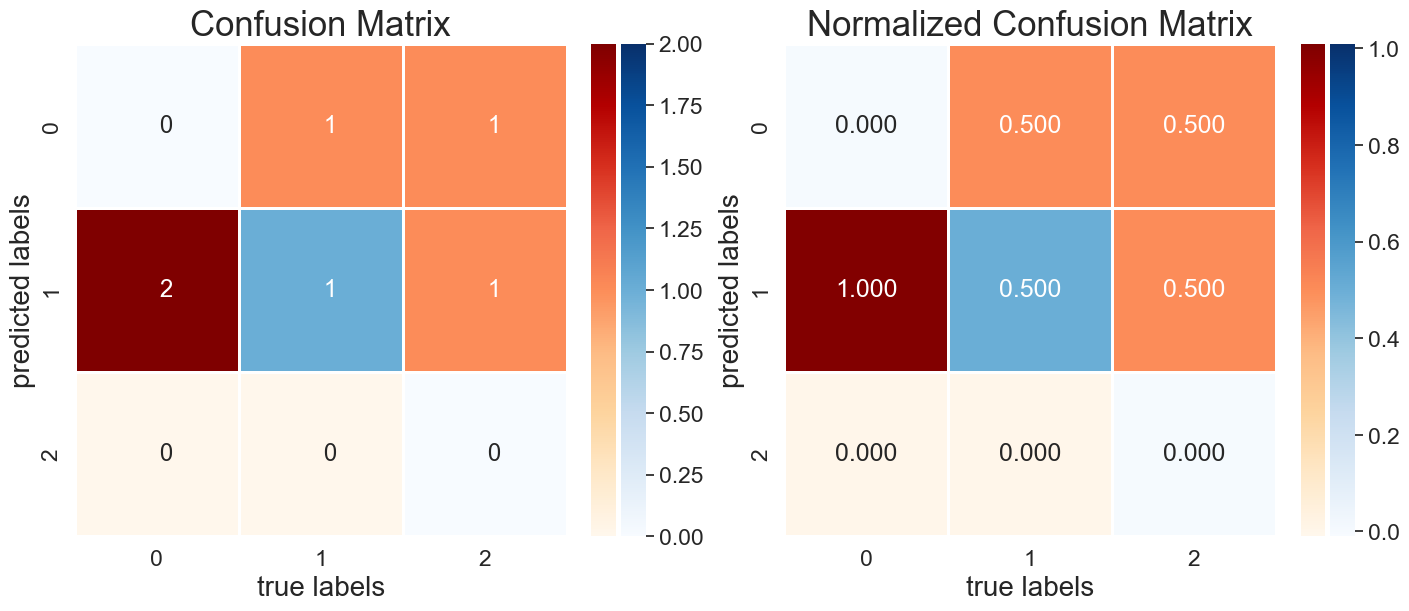

Balanced Accuracy:  16.67 %


In [ ]:
classlabels = y_test

scores = get_performances(
    loader2eval=testloader,
    Model=model_curr,
    device=device,
    nb_classes=nb_classes,
    return_scores=True,
    verbose=verbose,
    plot_confusion=True,
    class_labels=classlabels,
)
print(f"Balanced Accuracy: {scores['accuracy_weighted'] * 100: .2f} %")

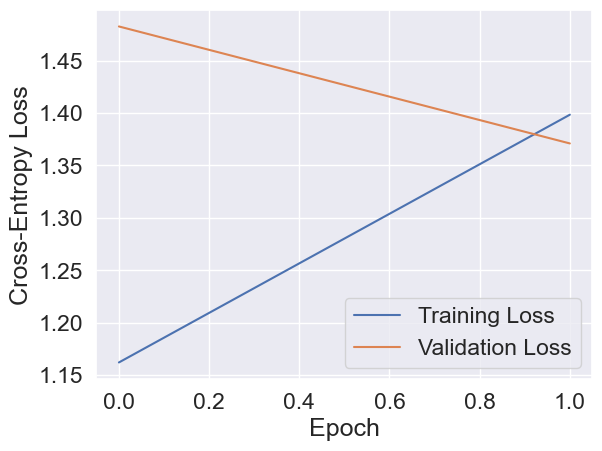

In [178]:
training_loss_curve = []
validation_loss_curve = []
# Iterate through the dictionary, filtering out entries with None values
for key, (train_loss, val_loss) in loss_summary.items():
    if train_loss is not None and val_loss is not None:
        training_loss_curve.append(train_loss)
        validation_loss_curve.append(val_loss)

scores["training_loss_curve"] = training_loss_curve
scores["validation_loss_curve"] = validation_loss_curve

plt.plot(training_loss_curve, label="Training Loss")
plt.plot(validation_loss_curve, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.show()

## Save the model


In [179]:
model_name = "xeeg_test_mini.pt"

dir_models = os.path.join(dir_shallownetXAI, "newmodels") + sep
model_path = os.path.join(dir_models, model_name)

dirResults = os.path.join(dir_shallownetXAI, "new_results") + sep
results_path = os.path.join(dirResults, f"{model_name[:-3]}_results.pickle")

In [180]:
results_path

'..\\..\\backend\\experiments_xeegnet\\shallownetXAI_main\\new_results\\xeeg_test_mini_results.pickle'

In [ ]:
print("model dir:", dir_models, os.path.isdir(dir_models))
print("model path:", model_path, os.path.abspath(model_path))
print("results dir:", dirResults, os.path.isdir(dirResults))
print(
    "results path:",
    results_path,
    os.path.abspath(results_path),
    os.path.exists(results_path),
)

model dir: ..\..\backend\experiments_xeegnet\shallownetXAI_main\newmodels\ True
model path: ..\..\backend\experiments_xeegnet\shallownetXAI_main\newmodels\xeeg_test_mini.pt c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\experiments_xeegnet\shallownetXAI_main\newmodels\xeeg_test_mini.pt
results dir: ..\..\backend\experiments_xeegnet\shallownetXAI_main\new_results\ True
results path: ..\..\backend\experiments_xeegnet\shallownetXAI_main\new_results\xeeg_test_mini_results.pickle c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\experiments_xeegnet\shallownetXAI_main\new_results\xeeg_test_mini_results.pickle True


In [183]:
save_model = False

if save_model:
    # Save the model
    model_curr.eval()
    model_curr.to(device="cpu")
    torch.save(model_curr.state_dict(), model_path)

    # Save the scores
    with open(results_path, "wb") as handle:
        pickle.dump(scores, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Compare training&inference times


In [ ]:
from time import time

In [ ]:
def inference(model, x: torch.Tensor | np.ndarray):
    model.eval()

    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x).float()
    with torch.no_grad():
        out = model(x)
    return out

In [ ]:
n_batches = 100
x = torch.randn(n_batches, Chans, sample_length, dtype=torch.float32)
cached_scc = torch.randn(n_batches, len(BANDS), Chans*(Chans-1)//2, dtype=torch.float32)

# xeegnet
current_time = time()
out = inference(xeegnet, x)
elapsed_time = time() - current_time
print(f"Elapsed time for {n_batches} batches: {elapsed_time:.4f} seconds for xeegnet")


# xeegnet_scc
current_time = time()
out = inference(xeegnet_scc, [x, cached_scc])
elapsed_time = time() - current_time
print(f"Elapsed time for {n_batches} batches: {elapsed_time:.4f} seconds for xeegnet_scc")

# shallownet
current_time = time()
out = inference(shallow_net, x)
elapsed_time = time() - current_time
print(f"Elapsed time for {n_batches} batches: {elapsed_time:.4f} seconds for shallownet")


Elapsed time for 100 batches: 0.0182 seconds for xeegnet
Elapsed time for 100 batches: 0.0126 seconds for xeegnet_scc
Elapsed time for 100 batches: 0.0701 seconds for shallownet


#### compare training time


In [ ]:
model_version = 200

n_max = 1500
n_max = None

parameters = PARAMETERS_DEFAULT
training_parameters = TRAINING_PARAMETERS_DEFAULT

In [ ]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
split_index = model_version - 200

if not n_max:
    modelname = f"xeegnet_scc_model_v{model_version}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname
else:
    modelname = f"xeegnet_scc_model_v{model_version}_nmax{n_max}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname

split_path = Path(dir_base) / "backend" / "ml" / "data_splits.json"

participants_split = load_participant_splits(split_path=split_path)[str(split_index)]


df_metadata = load_metadata(dir_data=dir_data)
df_metadata["datasplit"] = "test"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"
df_metadata.head()

df_metadata["datasplit"] = "test"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"
df_metadata.head()

,participant_id,Gender,Age,Group,MMSE,group_long,group_encoded,participant_id_int,datasplit
0,sub-001,F,57,A,16,Alzheimer Disease Group,1,1,train
1,sub-002,F,78,A,22,Alzheimer Disease Group,1,2,val
2,sub-003,M,70,A,14,Alzheimer Disease Group,1,3,val
3,sub-004,F,67,A,20,Alzheimer Disease Group,1,4,val
4,sub-005,M,70,A,22,Alzheimer Disease Group,1,5,val


In [ ]:
participant_ids_train=participant_ids[:5]
participant_ids_val=participant_ids[5:8]

In [ ]:
trainloader, valloader, testloader, data_tuple = get_dataloaders_xysubjectids(
    dir_data=dir_data,
    participant_ids_train=participant_ids_train,
    participant_ids_val=participant_ids_val,
    df_metadata=df_metadata,
    parameters=PARAMETERS_DEFAULT,
    # n_max=1000,
)

gamma = 0.995
# Define selfEEG's EarlyStopper with large patience to act as a model checkpoint
earlystop = selfeeg.ssl.EarlyStopping(
    patience=15, min_delta=1e-04, record_best_weights=True
)
validation_loss_args = []


Loaded derivative model windows: x shape (800, 19, 500), y shape (800,)
Loaded derivative model windows: x shape (547, 19, 500), y shape (547,)
Loaded derivative model windows: x shape (3164, 19, 500), y shape (3164,)


In [ ]:
trainloader_scc, valloader_scc, testloader_scc, data_tuple_scc = get_dataloaders_xysubjectids(
    dir_data=dir_data,
    participant_ids_train=participant_ids_train,
    participant_ids_val=participant_ids_val,
    df_metadata=df_metadata,
    parameters=PARAMETERS_DEFAULT,
    n_max=n_max,
    use_cached_scc=True,
    store=store,
    scc_params=params,
    dataset_id="ds004504",
    n_channels=Chans,
    source="derivatives",
    load_model_windows_for_participant=load_model_windows_for_participant,
)

print("trainloader_scc batches:", len(trainloader_scc))
print("valloader_scc batches:", len(valloader_scc))

Loaded x (800, 19, 500), scc (800, 7, 171), y (800,)
Loaded x (547, 19, 500), scc (547, 7, 171), y (547,)
Loaded x (3164, 19, 500), scc (3164, 7, 171), y (3164,)
trainloader_scc batches: 13
valloader_scc batches: 9


In [ ]:
## xeegnet_scc training

model_curr = build_xeegnet_scc(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, Fs=srate)

optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

current_time = time()

loss_summary = train_model(
    model=model_curr,
    train_dataloader=trainloader_scc,
    epochs=5,
    optimizer=optimizer,
    loss_func=lossMulti,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader_scc,
    validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

elaspsed_time = time() - current_time
print(f"Training completed in {elaspsed_time:.2f} seconds for xeegnet_scc.")

epoch [1/5]
   val 9/9: 100%|███████████████| 22/22 [53.37 Batch/s, train_loss=2.45407, val_loss=2.14129]  
epoch [2/5]
   val 9/9: 100%|███████████████| 22/22 [63.86 Batch/s, train_loss=2.41197, val_loss=1.84079]  
epoch [3/5]
   val 9/9: 100%|███████████████| 22/22 [66.06 Batch/s, train_loss=2.39445, val_loss=1.71608]  
epoch [4/5]
   val 9/9: 100%|███████████████| 22/22 [68.18 Batch/s, train_loss=2.36259, val_loss=1.60173]  
epoch [5/5]
   val 9/9: 100%|███████████████| 22/22 [61.03 Batch/s, train_loss=2.29600, val_loss=1.51843]  
Training completed in 1.79 seconds for xeegnet_scc.


In [ ]:
# xeegnet training
model_curr = xeegnet

optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

current_time = time()

loss_summary = train_model(
    model=model_curr,
    train_dataloader=trainloader,
    epochs=5,
    optimizer=optimizer,
    loss_func=lossMulti,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader, 
    validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

elaspsed_time = time() - current_time
print(f"Training completed in {elaspsed_time:.2f} seconds for xeegnet.")

epoch [1/5]
   val 9/9: 100%|███████████████| 22/22 [67.93 Batch/s, train_loss=1.77970, val_loss=2.78359]  
epoch [2/5]
   val 9/9: 100%|███████████████| 22/22 [69.38 Batch/s, train_loss=1.73629, val_loss=2.15271]  
epoch [3/5]
   val 9/9: 100%|███████████████| 22/22 [69.77 Batch/s, train_loss=1.66234, val_loss=2.02844]  
epoch [4/5]
   val 9/9: 100%|███████████████| 22/22 [52.57 Batch/s, train_loss=1.65616, val_loss=1.87270]  
epoch [5/5]
   val 9/9: 100%|███████████████| 22/22 [67.33 Batch/s, train_loss=1.63715, val_loss=1.90745]  
Training completed in 1.72 seconds for xeegnet.


In [ ]:
# #### shallow net

# # xeegnet training
# model_curr = shallow_net

# optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

# current_time = time()

# loss_summary = train_model(
#     model=model_curr,
#     train_dataloader=trainloader,
#     epochs=5,
#     optimizer=optimizer,
#     loss_func=lossMulti,
#     lr_scheduler=scheduler,
#     EarlyStopper=earlystop,
#     validation_dataloader=valloader,
#     validation_loss_func=lossVal,
#     validation_loss_args=validation_loss_args,
#     verbose=verbose,
#     device=device,
#     return_loss_info=True,
# )

# elaspsed_time = time() - current_time
# print(f"Training completed in {elaspsed_time:.2f} seconds for shallow_net.")